<a href="https://colab.research.google.com/github/adeleke1508/Ismail_Khaleed_3/blob/main/kmeans_clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [45]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import robust_scale, RobustScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv('/content/drive/MyDrive/content_refresh_anonymized.csv')
df.head()

,content_id,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,provider_used,model_used,impressions_90d,clicks_90d,pageviews_90d,sessions_90d,users_90d,engaged_sessions_90d,ai_sessions_90d,scroll_events_90d,days_with_impressions,days_with_sessions,impressions_last_30d,clicks_last_30d,sessions_last_30d,impressions_prev_30d,clicks_prev_30d,sessions_prev_30d,content_age_days,age_tier,age_tier_order,days_since_last_update,freshness_tier,word_count_tier,char_count_tier,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,impression_tier,position_tier,trend_direction,trend_pct
0,content_304f48230142,client_f369cb89fc,10.0,0.67,HIGH,2.05,keyword article,transactional,3221.0,20457.0,NaN,gemini-2.5-flash,3803,29,22,17,16,1,0,1,88,13,578,2,2,987,13,9,187,181-365,5,20,0-30,2000-3500,15000-25000,0.76,10.6,5.88,4.55,0.0,good,striking,down,-41.4
1,content_a1fb4e703a9e,client_4e07408562,90.0,0.01,LOW,0.05,keyword article,informational,2481.0,15562.0,NaN,gemini-3-flash-preview,15320,7,10,9,9,0,0,1,88,9,2501,2,3,5915,1,2,445,365+,6,25,0-30,2000-3500,15000-25000,0.05,20.3,0.00,10.00,0.0,good,page_3_5,down,-57.7
2,content_9aa793d4d895,client_7f2253d7e2,0.0,0.00,LOW,0.00,keyword article,informational,3515.0,23643.0,NaN,gemini-2.5-flash,12581,11,14,11,11,0,0,4,88,11,2382,1,1,6089,3,3,141,91-180,4,20,0-30,3500+,15000-25000,0.09,36.5,0.00,28.57,0.0,good,page_3_5,down,-60.9
3,content_331d6c4de07b,client_19581e27de,10.0,0.00,LOW,0.00,keyword article,commercial,NaN,NaN,NaN,NaN,11751,58,87,78,75,1,0,3,88,51,3626,22,35,4206,17,26,463,365+,6,22,0-30,NaN,NaN,0.49,6.2,1.28,3.45,0.0,good,page_1,stable,-13.8
4,content_d99b7a2d90ca,client_3fdba35f04,0.0,0.00,LOW,0.00,keyword article,informational,2803.0,17469.0,NaN,gemini-3-flash-preview,19140,24,177,145,144,0,0,43,88,33,4211,10,14,6452,2,9,263,181-365,5,14,0-30,2000-3500,15000-25000,0.13,44.0,0.00,24.29,0.0,good,page_3_5,down,-34.7


In [5]:
df.columns

Index(['content_id', 'client_id', 'search_volume', 'competition',
       'competition_level', 'cpc', 'content_type', 'main_intent', 'word_count',
       'char_count', 'provider_used', 'model_used', 'impressions_90d',
       'clicks_90d', 'pageviews_90d', 'sessions_90d', 'users_90d',
       'engaged_sessions_90d', 'ai_sessions_90d', 'scroll_events_90d',
       'days_with_impressions', 'days_with_sessions', 'impressions_last_30d',
       'clicks_last_30d', 'sessions_last_30d', 'impressions_prev_30d',
       'clicks_prev_30d', 'sessions_prev_30d', 'content_age_days', 'age_tier',
       'age_tier_order', 'days_since_last_update', 'freshness_tier',
       'word_count_tier', 'char_count_tier', 'ctr', 'avg_position',
       'engagement_rate', 'scroll_rate', 'ai_traffic_pct', 'impression_tier',
       'position_tier', 'trend_direction', 'trend_pct'],
      dtype='object')

In [25]:
sample_df = df[['ctr', 'impressions_90d', 'clicks_90d']]
sample_df

,ctr,impressions_90d,clicks_90d
0,0.76,3803,29
1,0.05,15320,7
2,0.09,12581,11
3,0.49,11751,58
4,0.13,19140,24
...,...,...,...
29995,0.00,1,0
29996,0.39,761,3
29997,0.19,6336,12
29998,0.22,154763,340


In [26]:
sample_df_imp_corr = sample_df['impressions_90d'].corr(sample_df['ctr'])
sample_df_clk_corr = sample_df['clicks_90d'].corr(sample_df['ctr'])
print(sample_df_imp_corr)
print(sample_df_clk_corr)

-0.01894973657977031
0.010608834300972191


In [13]:
sample_1_idx = sample_df['impressions_90d'] <50
sample_1 = sample_df.loc[sample_1_idx]
sample_1

,ctr,impressions_90d,clicks_90d
6,0.00,20,0
11,0.00,1,0
15,23.68,38,9
25,0.00,27,0
29,0.00,19,0
...,...,...,...
29981,0.00,3,0
29987,0.00,34,0
29988,0.00,2,0
29992,0.00,1,0


In [19]:
sample_1_imp_corr = sample_1['impressions_90d'].corr(sample_1['ctr'])
sample_1_clk_corr = sample_1['clicks_90d'].corr(sample_1['ctr'])
print(sample_1_imp_corr)
print(sample_1_clk_corr)

-0.0641527765895553
0.5348680159114783


In [16]:
sample_2_idx = sample_1['ctr'] > 5
sample_2 = sample_1.loc[sample_2_idx]
sample_2

,ctr,impressions_90d,clicks_90d
15,23.68,38,9
61,11.11,9,1
91,5.26,38,2
116,15.38,13,2
117,14.29,7,1
...,...,...,...
29404,16.67,6,1
29457,6.12,49,3
29538,7.14,28,2
29647,40.00,5,2


In [18]:
sample_2_imp_corr = sample_2['impressions_90d'].corr(sample_2['ctr'])
sample_2_clk_corr = sample_2['clicks_90d'].corr(sample_2['ctr'])
print(sample_2_imp_corr)
print(sample_2_clk_corr)

-0.5211574594837994
-0.03503851564659326


In [29]:
corr_compare = []
corr_compare.append({
    'sample_df_imp_corr': sample_df_imp_corr,
    'sample_df_clk_corr': sample_df_clk_corr,
    'sample_1_imp_corr': sample_1_imp_corr,
    'sample_1_clk_corr': sample_1_clk_corr,
    'sample_2_imp_corr': sample_2_imp_corr,
    'sample_2_clk_corr': sample_2_clk_corr
})
corr_df = pd.DataFrame(corr_compare)
corr_df

,sample_df_imp_corr,sample_df_clk_corr,sample_1_imp_corr,sample_1_clk_corr,sample_2_imp_corr,sample_2_clk_corr
0,-0.01895,0.010609,-0.064153,0.534868,-0.521157,-0.035039


In [37]:
features = ['impressions_90d', 'clicks_90d', 'ctr', 'word_count', 'search_volume']
X = df[features].copy().replace([np.inf, -np.inf], np.nan).dropna()
X_log = np.log1p(X)
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X_log)

In [40]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
cluster = kmeans.fit_predict(X_scaled)

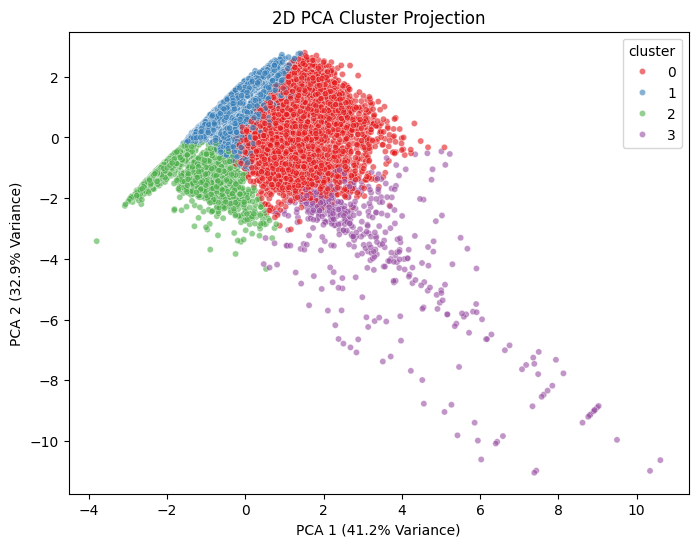

In [54]:
df_clean = df.loc[X.index].copy()
df_clean['cluster'] = cluster
pca = PCA(n_components=2)
pca_cords = pca.fit_transform(X_scaled)
df_clean['pca_1'] = pca_cords[:, 0]
df_clean['pca_2'] = pca_cords[:, 1]

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_clean,
    x='pca_1',
    y='pca_2',
    hue='cluster',
    palette='Set1',
    alpha=0.6,
    s = 20
)
plt.title('2D PCA Cluster Projection')
plt.xlabel(f'PCA 1 ({pca.explained_variance_ratio_[0]:.1%} Variance)')
plt.ylabel(f'PCA 2 ({pca.explained_variance_ratio_[1]:.1%} Variance)')
plt.show()

In [46]:
print(f'Silhouette Score: {silhouette_score(X_scaled, cluster):.4f}')
print(f'Davies Bouldins Score: {davies_bouldin_score(X_scaled, cluster):.4f}')
print(f'Calinski Harabasz Score: {calinski_harabasz_score(X_scaled, cluster):.4f}')

Silhouette Score: 0.2805
Davies Bouldins Score: 1.1752
Calinski Harabasz Score: 7090.7847


In [58]:
pd.crosstab(df_clean['cluster'], df_clean['content_type'], normalize='index') * 100


content_type,comparison article,keyword article
cluster,,
0,0.581934,99.418066
1,7.155163,92.844837
2,0.274725,99.725275
3,4.430380,95.569620


In [57]:
pd.crosstab(df_clean['cluster'], df_clean['trend_direction'], normalize='index') * 100

trend_direction,down,flat,new,stable,up
cluster,,,,,
0,57.598201,0.079355,0.978707,26.663140,14.680598
1,63.787757,5.558746,6.305272,12.828758,11.519467
2,57.356532,11.233211,13.949939,8.669109,8.791209
3,47.890295,5.485232,8.649789,16.244726,21.729958


In [59]:
cluster_names = {
    0: 'Pillar Staples',
    1: 'Decaying Giants',
    2: 'Emerging / Short Form',
    3: 'Rising Star'
}

df_clean['cluster_names'] = df_clean['cluster'].map(cluster_names)

In [61]:
df_clean

,content_id,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,provider_used,model_used,impressions_90d,clicks_90d,pageviews_90d,sessions_90d,users_90d,engaged_sessions_90d,ai_sessions_90d,scroll_events_90d,days_with_impressions,days_with_sessions,impressions_last_30d,clicks_last_30d,sessions_last_30d,impressions_prev_30d,clicks_prev_30d,sessions_prev_30d,content_age_days,age_tier,age_tier_order,days_since_last_update,freshness_tier,word_count_tier,char_count_tier,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,impression_tier,position_tier,trend_direction,trend_pct,cluster,pca_1,pca_2,cluster_names
0,content_304f48230142,client_f369cb89fc,10.0,0.67,HIGH,2.05,keyword article,transactional,3221.0,20457.0,NaN,gemini-2.5-flash,3803,29,22,17,16,1,0,1,88,13,578,2,2,987,13,9,187,181-365,5,20,0-30,2000-3500,15000-25000,0.76,10.6,5.88,4.55,0.00,good,striking,down,-41.4,0,1.503825,-0.754770,Pillar Staples
1,content_a1fb4e703a9e,client_4e07408562,90.0,0.01,LOW,0.05,keyword article,informational,2481.0,15562.0,NaN,gemini-3-flash-preview,15320,7,10,9,9,0,0,1,88,9,2501,2,3,5915,1,2,445,365+,6,25,0-30,2000-3500,15000-25000,0.05,20.3,0.00,10.00,0.00,good,page_3_5,down,-57.7,0,-0.363766,-0.071065,Pillar Staples
2,content_9aa793d4d895,client_7f2253d7e2,0.0,0.00,LOW,0.00,keyword article,informational,3515.0,23643.0,NaN,gemini-2.5-flash,12581,11,14,11,11,0,0,4,88,11,2382,1,1,6089,3,3,141,91-180,4,20,0-30,3500+,15000-25000,0.09,36.5,0.00,28.57,0.00,good,page_3_5,down,-60.9,0,0.491217,0.726377,Pillar Staples
4,content_d99b7a2d90ca,client_3fdba35f04,0.0,0.00,LOW,0.00,keyword article,informational,2803.0,17469.0,NaN,gemini-3-flash-preview,19140,24,177,145,144,0,0,43,88,33,4211,10,14,6452,2,9,263,181-365,5,14,0-30,2000-3500,15000-25000,0.13,44.0,0.00,24.29,0.00,good,page_3_5,down,-34.7,0,0.387326,0.177233,Pillar Staples
5,content_d4084a4bc775,client_f369cb89fc,720.0,1.00,HIGH,1.05,keyword article,transactional,3080.0,18178.0,NaN,gemini-2.5-flash,3970,1,4,5,5,0,0,1,88,5,617,0,4,1009,1,1,147,91-180,4,20,0-30,2000-3500,15000-25000,0.03,8.5,0.00,25.00,0.00,good,page_1,down,-38.9,1,-0.495091,0.318748,Decaying Giants
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29994,content_995627a1f490,client_7f2253d7e2,70.0,0.05,LOW,0.00,keyword article,transactional,2801.0,18452.0,google,gemini-3-flash-preview,349,3,6,5,5,0,0,1,71,5,38,1,1,111,0,1,96,91-180,4,20,0-30,2000-3500,15000-25000,0.86,4.6,0.00,16.67,0.00,moderate,page_1,down,-65.8,0,0.851092,-1.262395,Pillar Staples
29995,content_c322796023c8,client_e29c9c180c,10.0,0.05,LOW,0.00,keyword article,transactional,1386.0,9084.0,NaN,gemini-2.5-flash,1,0,3,3,3,0,0,0,1,3,1,0,2,0,0,1,347,181-365,5,20,0-30,1000-2000,8000-15000,0.00,0.0,0.00,0.00,0.00,low,top_3,new,NaN,2,-2.308791,-1.197425,Emerging / Short Form
29996,content_526572edb3fa,client_7f2253d7e2,0.0,0.00,LOW,0.00,keyword article,informational,2654.0,17056.0,google,gemini-3-flash-preview,761,3,3,3,3,0,0,2,77,3,44,1,1,177,0,1,96,91-180,4,20,0-30,2000-3500,15000-25000,0.39,6.6,0.00,66.67,0.00,moderate,page_1,down,-75.1,0,0.282320,-0.465091,Pillar Staples
29997,content_38112bdd0c6e,client_349c41201b,10.0,1.00,HIGH,0.00,keyword article,transactional,2857.0,18725.0,google,gemini-3-flash-preview,6336,12,45,44,44,0,0,0,88,18,404,0,16,1194,4,15,124,91-180,4,20,0-30,2000-3500,15000-25000,0.19,4.1,0.00,0.00,0.00,good,page_1,down,-66.2,0,0.255480,-0.025758,Pillar Staples


1. Cluster 0: "Pillar Staples" (or Core Performers)The Data: High Impressions ($6,079$), High Clicks ($15$), Long-form ($3,089$ words), high proportion of Stable traffic ($26.7\%$).Why this name? These are your heavy lifters driving the vast majority of organic visibility and traffic.Editorial Action: Protect & Maintain (Keep updated to prevent traffic decay).
2. Cluster 1: "Decaying Giants" (or Stagnant Long-form)The Data: High word count ($3,035$ words), but low impressions ($271$), $0$ clicks, and the highest rate of traffic decline ($63.8\%$ Down).Why this name? Significant effort went into creating these long articles, but they are losing search authority and failing to convert impressions into clicks.Editorial Action: SEO Audit & Refresh (Update search intent, fix technical indexation, or refresh keywords).
3. Cluster 2: "Emerging / Short-Form" (or Gaps & Stubs)The Data: Shortest word count ($1,479$ words), highest share of Brand New content ($14.0\%$) and highest Search Volume ($10$).Why this name? This segment represents newer articles that haven't fully matured yet, alongside thin/short-form content targeting competitive terms.Editorial Action: Expand & Consolidate (Give new articles time to rank, or expand thin content to compete).
4. Cluster 3: "Rising Stars" (or High-CTR Micro-Niches)The Data: Low impressions ($54.5$), high CTR ($2.5\%$), and the highest proportion of growing traffic ($21.7\%$ Up).Why this name? When people see this content, they click. Traffic is actively trending upward, even if current overall reach is still small.Editorial Action: Scale & Promote (Build internal links and boost distribution to expand impression reach).